In [1]:
# import libraries

import deeplabcut
import zipfile
import cv2
import os
import shutil
import glob
import pandas as pd

Loading DLC 3.0.0rc6...


### *Step1: load the function we have provided*

In [2]:
# given a video file, extract frames and save them in a folder
# the function assumes that the video is from the combined calibration video
def get__checkerboard_frames(calib_video_path, main_folder, jump = 1, total_calib_frames = 20):
    # create directory for frames 
    frames_folder = os.path.join(main_folder, 'checkerboard_Frames')
    if not os.path.exists(frames_folder):  
        os.makedirs(frames_folder)
    

    cap = cv2.VideoCapture(calib_video_path)
    total_frames = total_calib_frames
    #frames_interval = 
    
    frame_number = 0
    while cap.isOpened():

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
        ret, frame = cap.read()
        height, width, _ = frame.shape
        middle = width // 2

        camera1_frame = frame[:,:middle]
        camera2_frame = frame[:,middle:]

        frame_num_str = f'{frame_number + 1:02d}'

        # Save the left and right parts with appropriate names
        camera1_filename = os.path.join(frames_folder, f'camera-1-{frame_num_str}.jpg')
        camera2_filename = os.path.join(frames_folder, f'camera-2-{frame_num_str}.jpg')

        cv2.imwrite(camera1_filename, camera1_frame)
        cv2.imwrite(camera2_filename, camera2_frame)

        frame_number += jump

        if frame_number == total_frames:
            break

    cap.release()
    # cv2.destroyAllWindows()
        

In [3]:
# optional function for zooming into the center of the images

def zoom_into_center(main_folder, zoom_factor=1.5, camera_prefixs = ["camera-1", "camera-2"]):
    calibrated_images_folder = os.path.join(main_folder, 'checkerboard_Frames')
    for camera_prefix in camera_prefixs:
        camera_images = glob.glob(os.path.join(calibrated_images_folder, f"{camera_prefix}-*.jpg"))

        for image_path in camera_images:
            image = cv2.imread(image_path)
            height, width = image.shape[:2]

            # Step 1: Calculate the cropping box for zooming
            center_x, center_y = width // 2, height // 2
            box_width = int(width / zoom_factor)
            box_height = int(height / zoom_factor)

            x1 = max(center_x - box_width // 2, 0)
            y1 = max(center_y - box_height // 2, 0)
            x2 = min(center_x + box_width // 2, width)
            y2 = min(center_y + box_height // 2, height)

            # Step 2: Crop the center region
            cropped_image = image[y1:y2, x1:x2]

            # Step 3: Resize back to original dimensions
            zoomed_image = cv2.resize(cropped_image, (width, height), interpolation=cv2.INTER_LINEAR)

            # Save the modified image directly to the same file
            cv2.imwrite(image_path, zoomed_image)
            print(f"Zoomed into center: {image_path}")

In [4]:
def contour_enhancment(main_folder, cliplimit, tilegridsize, alpha, beta, sharpness, camera_prefixs = ["camera-1", "camera-2"]):
  calibrated_images_folder = os.path.join(main_folder, 'checkerboard_Frames')
  for camera_prefix in camera_prefixs:
        camera_images = glob.glob(os.path.join(calibrated_images_folder, f"{camera_prefix}-*.jpg"))

        for image_path in camera_images:
            image = cv2.imread(image_path)

            # Convert to grayscale for CLAHE
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

            # Apply CLAHE
            clahe = cv2.createCLAHE(clipLimit=cliplimit, tileGridSize=(int(tilegridsize),int(tilegridsize)))
            enhanced = clahe.apply(gray)

            # Adjust brightness and contrast
            adjusted = cv2.convertScaleAbs(enhanced, alpha=alpha, beta=beta)

            # Apply sharpening
            blurred = cv2.GaussianBlur(adjusted, (5, 5), 1)
            sharpened = cv2.addWeighted(adjusted, 1.0 + sharpness, blurred, -sharpness, 0)

            cv2.imwrite(image_path, sharpened)
            print(f"Adjusted: {image_path}")


In [5]:
def move_files(main_folder, project_name):
    src_path = os.path.join(main_folder, 'checkerboard_Frames')
    dst_path = os.path.join(main_folder, project_name, 'calibration_images')

    for filename in os.listdir(src_path):
        src_file = os.path.join(src_path, filename)
        dst_file = os.path.join(dst_path, filename)
        shutil.move(src_file, dst_file)

In [6]:
main_folder = # path to the main parent folder
calib_video_path = # path to the video of the checkerboard
mouse_video_folder_path = # path to the folder that contain the mouse video we want to triangulate
3D_congif_yaml_path = # path to the 3D congif yaml file

get__checkerboard_frames(calib_video_path, main_folder, jump = 1, total_calib_frames = 80)
zoom_into_center(main_folder, zoom_factor=1.5, camera_prefixs = ["camera-2"])
contour_enhancment(main_folder, 2, 8, 1.0, 10, 0, camera_prefixs = ["camera-2"])

project_name ='ProjectName'
experimenter_name = 'NameofLabeler'
config_path3d = deeplabcut.create_new_project_3d(project_name,
                                                 experimenter_name,
                                                 num_cameras = 2,
                                                working_directory=main_folder)

project_path = os.path.dirname(config_path3d)
project_name = os.path.basename(project_path)
move_files(main_folder, project_name)

Zoomed into center: E:\sharbel-sivan-E\checkerboard_Frames\camera-2-01.jpg
Zoomed into center: E:\sharbel-sivan-E\checkerboard_Frames\camera-2-02.jpg
Zoomed into center: E:\sharbel-sivan-E\checkerboard_Frames\camera-2-03.jpg
Zoomed into center: E:\sharbel-sivan-E\checkerboard_Frames\camera-2-04.jpg
Zoomed into center: E:\sharbel-sivan-E\checkerboard_Frames\camera-2-05.jpg
Zoomed into center: E:\sharbel-sivan-E\checkerboard_Frames\camera-2-06.jpg
Zoomed into center: E:\sharbel-sivan-E\checkerboard_Frames\camera-2-07.jpg
Zoomed into center: E:\sharbel-sivan-E\checkerboard_Frames\camera-2-08.jpg
Zoomed into center: E:\sharbel-sivan-E\checkerboard_Frames\camera-2-09.jpg
Zoomed into center: E:\sharbel-sivan-E\checkerboard_Frames\camera-2-10.jpg
Zoomed into center: E:\sharbel-sivan-E\checkerboard_Frames\camera-2-11.jpg
Zoomed into center: E:\sharbel-sivan-E\checkerboard_Frames\camera-2-12.jpg
Zoomed into center: E:\sharbel-sivan-E\checkerboard_Frames\camera-2-13.jpg
Zoomed into center: E:\sh

In [7]:
deeplabcut.calibrate_cameras(config_path3d, cbrow=5, cbcol=7, calibrate=False, alpha=0.8)

Corners not found for the image camera-1-03.jpg
Corners not found for the image camera-1-05.jpg
Corners not found for the image camera-1-10.jpg
Corners not found for the image camera-1-12.jpg
Corners not found for the image camera-1-22.jpg
Corners not found for the image camera-1-47.jpg
Corners not found for the image camera-1-48.jpg
Corners not found for the image camera-1-51.jpg
Corners not found for the image camera-1-52.jpg
Corners not found for the image camera-1-62.jpg
Corners not found for the image camera-1-64.jpg
Corners not found for the image camera-1-65.jpg
Corners not found for the image camera-1-67.jpg
Corners not found for the image camera-2-06.jpg
Corners not found for the image camera-2-08.jpg
Corners not found for the image camera-2-09.jpg
Corners not found for the image camera-2-13.jpg
Corners not found for the image camera-2-15.jpg
Corners not found for the image camera-2-16.jpg
Corners not found for the image camera-2-17.jpg
Corners not found for the image camera-2

In [8]:
deeplabcut.calibrate_cameras(config_path3d, cbrow=5, cbcol=7, calibrate=True, alpha=0.8)

Saving intrinsic camera calibration matrices for camera-1 as a pickle file in E:\sharbel-sivan-E\ProjectName-NameofLabeler-2025-04-27-3d\camera_matrix
Mean re-projection error for camera-1 images: 0.080 pixels 
Saving intrinsic camera calibration matrices for camera-2 as a pickle file in E:\sharbel-sivan-E\ProjectName-NameofLabeler-2025-04-27-3d\camera_matrix
Mean re-projection error for camera-2 images: 0.300 pixels 
Computing stereo calibration for 
Saving the stereo parameters for every pair of cameras as a pickle file in E:\sharbel-sivan-E\ProjectName-NameofLabeler-2025-04-27-3d\camera_matrix
Camera calibration done! Use the function ``check_undistortion`` to check the check the calibration


All images are undistorted and stored in E:\sharbel-sivan-E\ProjectName-NameofLabeler-2025-04-27-3d\undistortion
Use the function ``triangulate`` to undistort the dataframes and compute the triangulation


C:\Users\Jackie\Anaconda3\envs\dlc\lib\site-packages\deeplabcut\utils\auxiliaryfunctions_3d.py:105: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(xs, ys, zs, c=col[i], marker=markerType, s=markerSize)


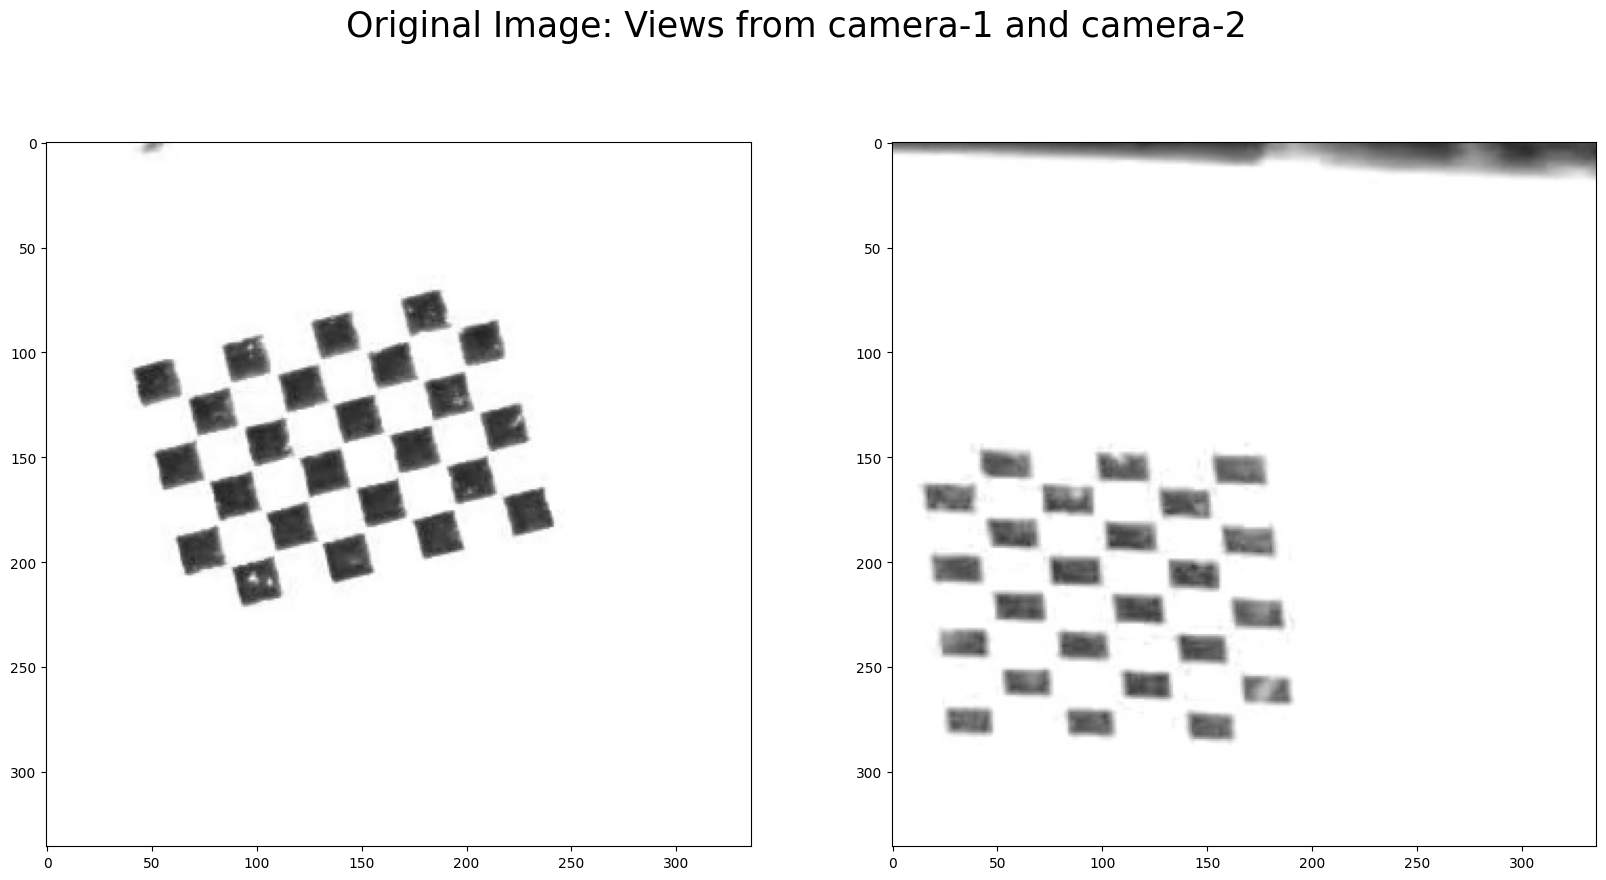

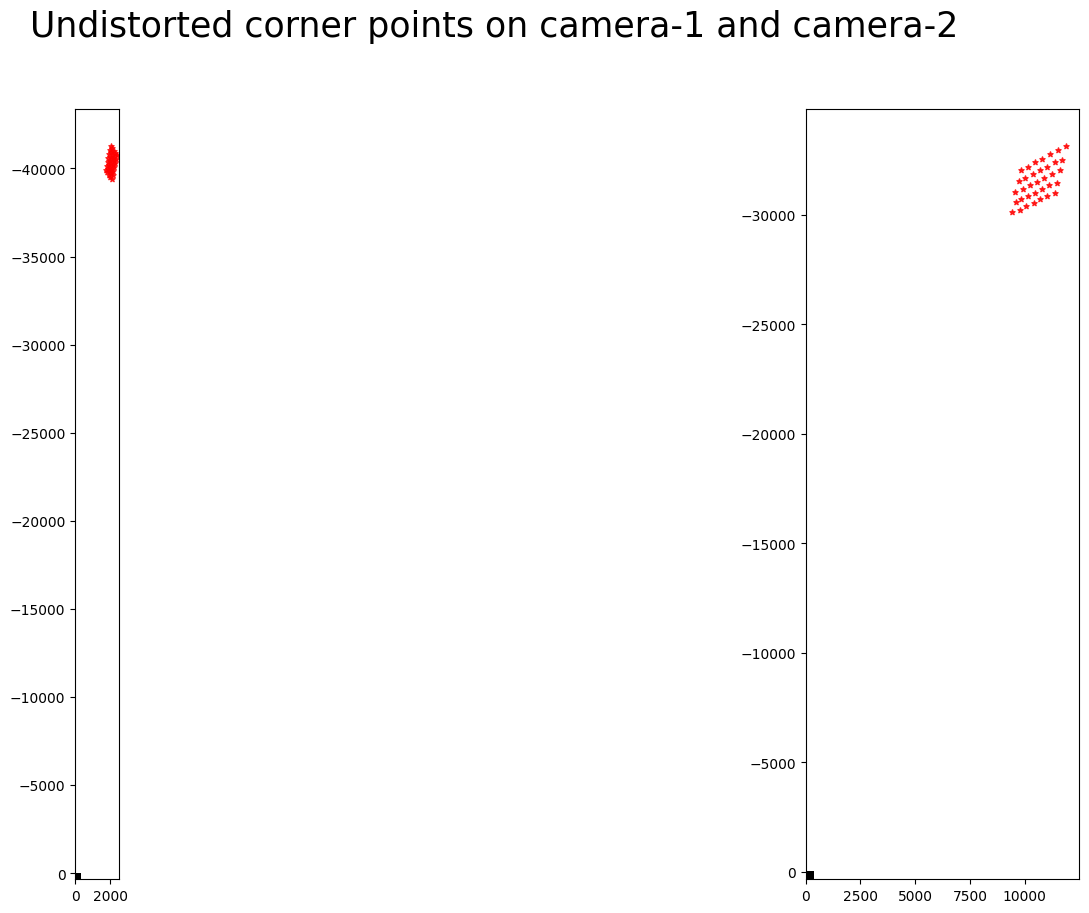

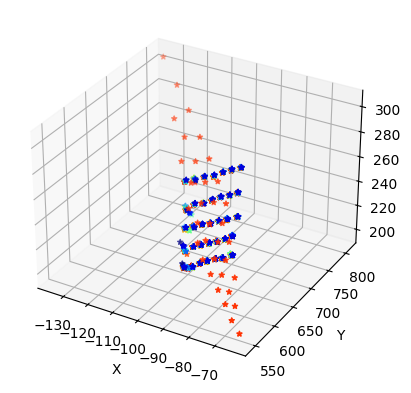

In [9]:
deeplabcut.check_undistortion(config_path3d, cbrow=5, cbcol=7)

In [15]:
deeplabcut.triangulate(config_path3d, mouse_video_folder_path, filterpredictions=True, save_as_csv=True)

List of pairs: [['E:\\sharbel-sivan-E\\mouse_videos\\mouse_video_camera-1.mp4', 'E:\\sharbel-sivan-E\\mouse_videos\\mouse_video_camera-2.mp4']]
Analyzing video E:\sharbel-sivan-E\mouse_videos\mouse_video_camera-1.mp4 using config_file_camera-1
Analyzing videos with E:\sharbel-sivan-E\camera-1-Sharbel-Sivan-2024-12-18\dlc-models-pytorch\iteration-0\camera-1Dec18-trainset95shuffle1\train\snapshot-best-090.pt


C:\Users\Jackie\Anaconda3\envs\dlc\lib\site-packages\deeplabcut\pose_estimation_pytorch\runners\base.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  snapshot = torch.lo

Video E:\sharbel-sivan-E\mouse_videos\mouse_video_camera-1.mp4 already analyzed at E:\sharbel-sivan-E\mouse_videos\mouse_video_camera-1DLC_Resnet50_camera-1Dec18shuffle1_snapshot_090_full.pickle!
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

E:\sharbel-sivan-E\mouse_videos mouse_video_camera-1 DLC_Resnet50_camera-1Dec18shuffle1_snapshot_090
Filtering with median model E:\sharbel-sivan-E\mouse_videos\mouse_video_camera-1.mp4
Data from mouse_video_camera-1 were already filtered. Skipping...
Analyzing video E:\sharbel-sivan-E\mouse_videos\mouse_video_camera-2.mp4 using config_file_camera-2
Analyzing videos with E:\sharbel-sivan-E\camera-2-Sharbel-Sivan-2024-12-19\dlc-models-pytorch\iteration-0\camera-2Dec19-trainset95shuffle1\train

C:\Users\Jackie\Anaconda3\envs\dlc\lib\site-packages\deeplabcut\pose_estimation_pytorch\runners\base.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  snapshot = torch.lo

Video E:\sharbel-sivan-E\mouse_videos\mouse_video_camera-2.mp4 already analyzed at E:\sharbel-sivan-E\mouse_videos\mouse_video_camera-2DLC_Resnet50_camera-2Dec19shuffle1_snapshot_150_full.pickle!
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

E:\sharbel-sivan-E\mouse_videos mouse_video_camera-2 DLC_Resnet50_camera-2Dec19shuffle1_snapshot_150
Filtering with median model E:\sharbel-sivan-E\mouse_videos\mouse_video_camera-2.mp4
Data from mouse_video_camera-2 were already filtered. Skipping...
Undistorting...
Computing the triangulation...
Triangulated data for video E:\sharbel-sivan-E\mouse_videos\mouse_video_camera-2.mp4
Results are saved under:  E:\sharbel-sivan-E\mouse_videos
All videos were analyzed...
Now you can create 3D vide

In [16]:
file_path = # path to the h5 file of data that is the output of the trinagulate
df_3d = pd.read_hdf(file_path)

print(df_3d.columns)

MultiIndex([('DLC_3D', 'right_hand_center', 'x'),
            ('DLC_3D', 'right_hand_center', 'y'),
            ('DLC_3D', 'right_hand_center', 'z'),
            ('DLC_3D',     'right_finger1', 'x'),
            ('DLC_3D',     'right_finger1', 'y'),
            ('DLC_3D',     'right_finger1', 'z'),
            ('DLC_3D',     'right_finger2', 'x'),
            ('DLC_3D',     'right_finger2', 'y'),
            ('DLC_3D',     'right_finger2', 'z'),
            ('DLC_3D',     'right_finger3', 'x'),
            ('DLC_3D',     'right_finger3', 'y'),
            ('DLC_3D',     'right_finger3', 'z'),
            ('DLC_3D',     'right_finger4', 'x'),
            ('DLC_3D',     'right_finger4', 'y'),
            ('DLC_3D',     'right_finger4', 'z'),
            ('DLC_3D',  'left_hand_center', 'x'),
            ('DLC_3D',  'left_hand_center', 'y'),
            ('DLC_3D',  'left_hand_center', 'z'),
            ('DLC_3D',      'left_finger1', 'x'),
            ('DLC_3D',      'left_finger1', 'y'),


In [17]:
# Calculate min and max for each coordinate across all body parts
x_min, x_max = df_3d.xs('x', level='coords', axis=1).min().min(), df_3d.xs('x', level='coords', axis=1).max().max()
y_min, y_max = df_3d.xs('y', level='coords', axis=1).min().min(), df_3d.xs('y', level='coords', axis=1).max().max()
z_min, z_max = df_3d.xs('z', level='coords', axis=1).min().min(), df_3d.xs('z', level='coords', axis=1).max().max()

print("X axis range:", x_min, "to", x_max)
print("Y axis range:", y_min, "to", y_max)
print("Z axis range:", z_min, "to", z_max)


X axis range: -150.33012 to -54.619858
Y axis range: 589.4624 to 949.4052
Z axis range: 213.76257 to 373.98755


Analyzing all the videos in the directory
[['E:\\sharbel-sivan-E\\mouse_videos\\mouse_video_DLC_3D.h5', 'E:\\sharbel-sivan-E\\mouse_videos\\mouse_video_camera-1.mp4', 'E:\\sharbel-sivan-E\\mouse_videos\\mouse_video_camera-2.mp4']]
Creating 3D video from mouse_video_camera-1.mp4 and mouse_video_camera-2.mp4 using mouse_video_DLC_3D.h5
Looking for filtered predictions...
Found the following filtered data:  E:\sharbel-sivan-E\mouse_videos\*mouse_video_camera-1DLC_Resnet50_camera-1Nov26shuffle1_snapshot_040*filtered.h5 E:\sharbel-sivan-E\mouse_videos\*mouse_video_camera-2DLC_Resnet50_camera-2Nov25shuffle1_snapshot_140*filtered.h5


100%|████████████████████████████████████████████████████████████████████████| 129600/129600 [6:52:45<00:00,  5.23it/s]


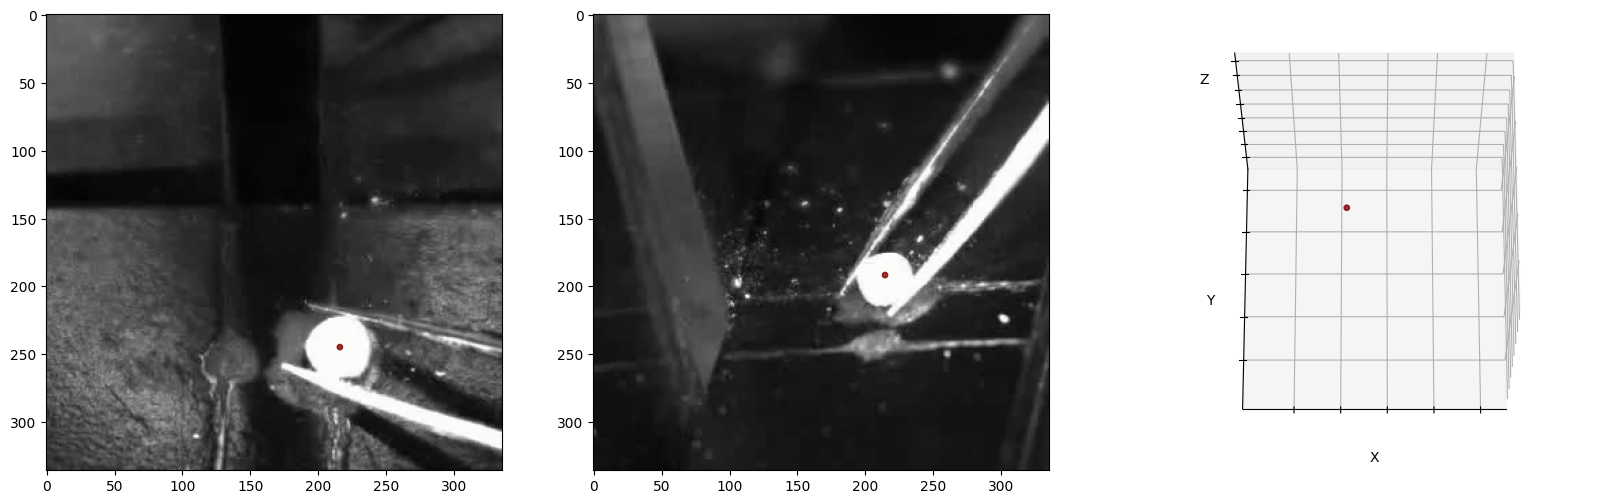

In [17]:
deeplabcut.create_labeled_video_3d(
    3D_congif_yaml_path,
    [mouse_video_folder_path],
    start=0, videotype='.mp4',
    xlim=[x_min, x_max],
    ylim=[y_min, y_max],
    zlim=[z_min, z_max],
    fps=180
)
